# Employee Sentiment Analysis

This project analyzes employee email communications to determine sentiment trends,
employee engagement, and potential flight risks using Natural Language Processing (NLP)
and statistical modeling techniques.

The dataset consists of employee messages with sender, date, and message body fields.

Objectives of the project include:
- Sentiment labeling of messages
- Exploratory data analysis (EDA)
- Monthly sentiment scoring per employee
- Employee ranking
- Flight risk detection
- Predictive modeling using linear regression

## 1. Data Loading and Preprocessing

In this step we load the dataset and perform initial preprocessing.
The date column is converted into datetime format and a new month
column is created to enable monthly sentiment analysis.

In [1]:
import pandas as pd

df = pd.read_csv("../data/test.csv")

df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.to_period('M')

In [2]:
df.head()

,Subject,body,date,from,month
0,EnronOptions Update!,EnronOptions Announcement\n\n\nWe have updated...,2010-05-10,sally.beck@enron.com,2010-05
1,(No Subject),"Marc,\n\nUnfortunately, today is not going to ...",2010-07-29,eric.bass@enron.com,2010-07
2,Phone Screen Interview - Shannon L. Burnham,"When: Wednesday, June 06, 2001 10:00 AM-11:00 ...",2011-07-25,sally.beck@enron.com,2011-07
3,RE: My new work email,we were thinking papasitos (we can meet somewh...,2010-03-25,johnny.palmer@enron.com,2010-03
4,Bet,Since you never gave me the $20 for the last t...,2011-05-21,lydia.delgado@enron.com,2011-05


## 2. Sentiment Labeling

Employee messages are classified into three categories:
- Positive
- Negative
- Neutral

We use the VADER sentiment analyzer from the NLTK library, which
is optimized for social and conversational text.

In [3]:
from textblob import TextBlob

def get_sentiment(text):
    polarity = TextBlob(str(text)).sentiment.polarity
    
    if polarity > 0.1:
        return "Positive"
    elif polarity < -0.1:
        return "Negative"
    else:
        return "Neutral"

df['sentiment'] = df['body'].apply(get_sentiment)

df[['body','sentiment']].head()

,body,sentiment
0,EnronOptions Announcement\n\n\nWe have updated...,Positive
1,"Marc,\n\nUnfortunately, today is not going to ...",Neutral
2,"When: Wednesday, June 06, 2001 10:00 AM-11:00 ...",Neutral
3,we were thinking papasitos (we can meet somewh...,Negative
4,Since you never gave me the $20 for the last t...,Neutral


## 3. Sentiment Score Calculation

Each message is assigned a sentiment score:

Positive = +1  
Negative = -1  
Neutral = 0  

These scores are later aggregated monthly for each employee.

In [4]:
score_map = {
    "Positive":1,
    "Negative":-1,
    "Neutral":0
}

df['score'] = df['sentiment'].map(score_map)

In [5]:
df[['sentiment','score']].head()

,sentiment,score
0,Positive,1
1,Neutral,0
2,Neutral,0
3,Negative,-1
4,Neutral,0


## 4. Monthly Employee Sentiment Score

To evaluate employee engagement trends, sentiment scores are aggregated
for each employee on a monthly basis.

In [6]:
employee_month_score = (
    df.groupby(['from','month'])['score']
    .sum()
    .reset_index()
)

## 5. Employee Ranking

Employees are ranked based on their monthly sentiment scores.

Two lists are generated:
- Top 3 positive employees
- Top 3 negative employees

In [7]:
top_positive = (
employee_month_score
.sort_values(['month','score'],ascending=[True,False])
.groupby('month')
.head(3)
)
top_positive.head()

,from,month,score
120,kayne.coulter@enron.com,2010-01,5
168,patti.thompson@enron.com,2010-01,5
24,don.baughman@enron.com,2010-01,4
1,bobette.riner@ipgdirect.com,2010-02,7
73,john.arnold@enron.com,2010-02,7


In [8]:
top_negative = (
employee_month_score
.sort_values(['month','score'])
.groupby('month')
.head(3)
)

## 6. Flight Risk Detection

An employee is considered a flight risk if they send 4 or more negative
emails within a rolling 30-day period.

This rolling window approach helps identify sustained negative sentiment.

In [9]:
df['date'] = pd.to_datetime(df['date'])

neg = df[df['sentiment']=="Negative"]

# IMPORTANT STEP
neg = neg.sort_values(['from','date'])

flight_risk = (
    neg.groupby('from')
    .rolling('30D', on='date')['body']
    .count()
    .reset_index(name='neg_count')
)

flight_risk = flight_risk[flight_risk['neg_count'] >= 4]

flight_risk_employees = flight_risk['from'].unique()

In [10]:
df['msg_length'] = df['body'].str.len()
df['word_count'] = df['body'].str.split().apply(len)

## 7. Predictive Modeling

A linear regression model is used to analyze how certain features influence
employee sentiment scores.

Features used:
- Average message length
- Average word count
- Message frequency

In [11]:
features = df.groupby(['from','month']).agg({
'msg_length':'mean',
'word_count':'mean',
'body':'count',
'score':'sum'
}).reset_index()

features.rename(columns={'body':'msg_count'},inplace=True)

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = features[['msg_length','word_count','msg_count']]
y = features['score']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

model = LinearRegression()
model.fit(X_train,y_train)

pred = model.predict(X_test)

## 8. Exploratory Data Analysis and Visualizations

Several visualizations are generated to understand sentiment distribution,
employee engagement patterns, and sentiment trends over time.

<Axes: xlabel='sentiment', ylabel='count'>

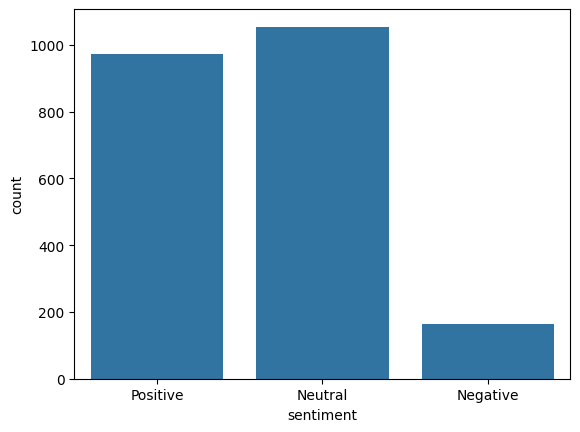

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='sentiment',data=df)

<Axes: xlabel='month'>

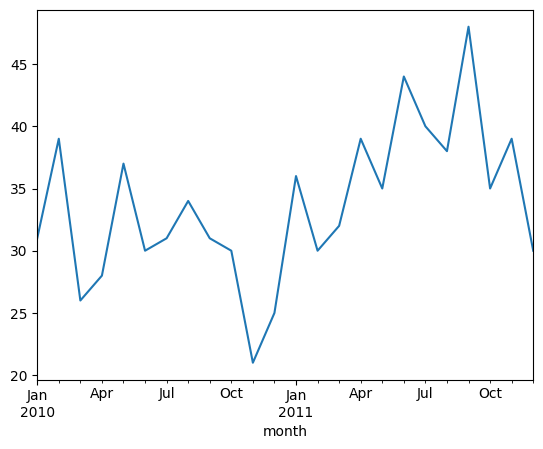

In [14]:
df.groupby('month')['score'].sum().plot()

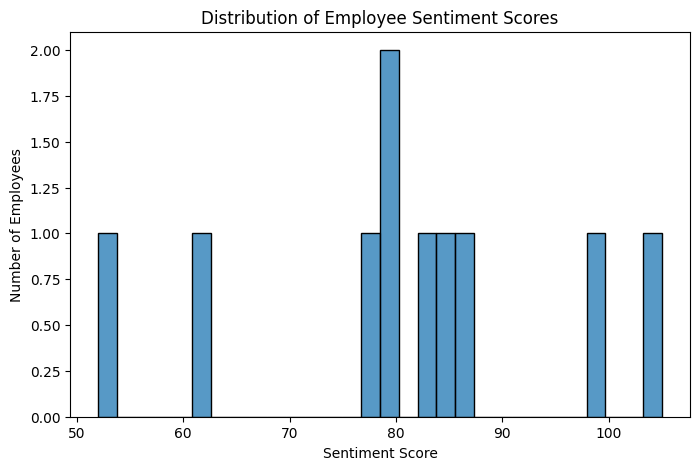

In [15]:
employee_scores = df.groupby("from")["score"].sum()

plt.figure(figsize=(8,5))

sns.histplot(employee_scores, bins=30)

plt.title("Distribution of Employee Sentiment Scores")
plt.xlabel("Sentiment Score")
plt.ylabel("Number of Employees")

plt.show()

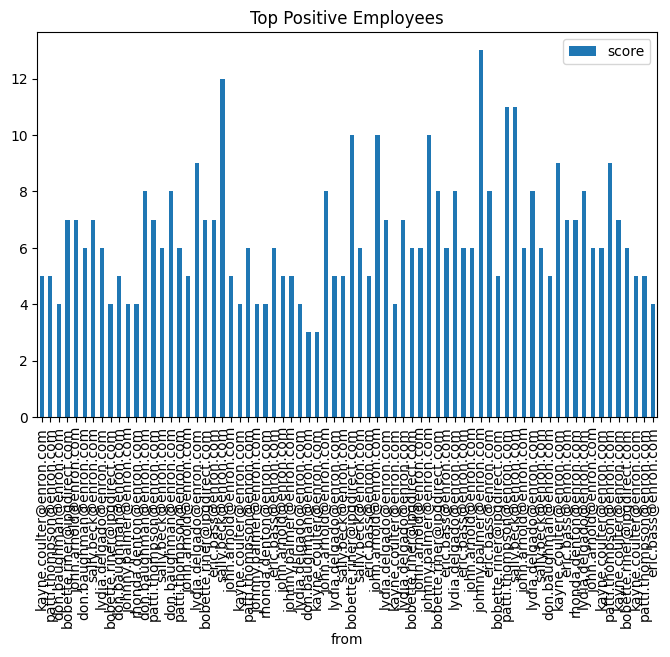

In [16]:
top_positive.plot(
    x="from",
    y="score",
    kind="bar",
    figsize=(8,5)
)

plt.title("Top Positive Employees")

plt.show()

## 9. Conclusion

This analysis provides insights into employee communication sentiment
and identifies individuals who may be at risk of disengagement.

The combination of sentiment analysis and statistical modeling helps
organizations monitor employee engagement and proactively address issues.